In [1]:
import pandas as pd
import numpy as np



In [2]:
def run_ecom_etl(input_csv_path: str) -> pd.DataFrame:
    print(f"[ETL] Initializing pipeline ingestion for: {input_csv_path}")

    df = pd.read_csv(input_csv_path)

    df = df[df['CustomerID'].notnull()]
    df = df[df['Quantity'] > 0]
    df = df[df['UnitPrice'] > 0]
    df = df.drop_duplicates()

    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

    df['Revenue'] = df['Quantity'] * df['UnitPrice']
    df['ActivityMonth'] = df['InvoiceDate'].dt.to_period('M')

    cohort = df.groupby('CustomerID')['InvoiceDate'].min().reset_index()
    cohort.columns = ['CustomerID', 'CohortDate']
    cohort['CohortMonth'] = cohort['CohortDate'].dt.to_period('M')

    processed_df = pd.merge(
        df,
        cohort[['CustomerID', 'CohortMonth']],
        on='CustomerID'
    )

    processed_df['CohortIndex'] = (
        (processed_df['ActivityMonth'].dt.year -
         processed_df['CohortMonth'].dt.year) * 12
        +
        (processed_df['ActivityMonth'].dt.month -
         processed_df['CohortMonth'].dt.month)
    )

    print(f"[ETL] Success. Processed records: {processed_df.shape[0]}")

    return processed_df

In [3]:
input_file = r"C:\Users\chakr\Desktop\ecommerce.csv"

clean_df = run_ecom_etl(input_file)

clean_df.head()

[ETL] Initializing pipeline ingestion for: C:\Users\chakr\Desktop\ecommerce.csv
[ETL] Success. Processed records: 392691


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,ActivityMonth,CohortMonth,CohortIndex
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.55,17850.0,United Kingdom,15.30,2010-12,2010-12,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.75,17850.0,United Kingdom,22.00,2010-12,2010-12,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12,0


In [16]:
# Cell 1: Pipeline Compilation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# Load data natively from our system folder structure
df = pd.read_csv( r"C:\Users\chakr\Desktop\ecommerce.csv")


In [18]:
column_mapping = {
    'customerid': 'CustomerID',
    'customer_id': 'CustomerID',
    'invoicedate': 'InvoiceDate',
    'invoice_date': 'InvoiceDate',
    'unitprice': 'UnitPrice',
    'unit_price': 'UnitPrice',
    'quantity': 'Quantity',
    'revenue': 'Revenue'
}

df = df.rename(columns=lambda x: column_mapping.get(x.lower(), x))

print("Columns after normalization:", df.columns.tolist())


Columns after normalization: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [24]:
#Revenue column-

df['Revenue'] = df['Quantity'] * df['UnitPrice']

#Invoice Month-

df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

  InvoiceDate  UnitPrice  CustomerID         Country ActivityMonth  \
0  2010-12-01       2.55     17850.0  United Kingdom       2010-12   
1  2010-12-01       3.39     17850.0  United Kingdom       2010-12   
2  2010-12-01       2.75     17850.0  United Kingdom       2010-12   
3  2010-12-01       3.39     17850.0  United Kingdom       2010-12   
4  2010-12-01       3.39     17850.0  United Kingdom       2010-12   

  CohortMonth_x CohortMonth_y CohortMonth  Revenue InvoiceMonth  
0       2010-12       2010-12     2010-12    15.30      2010-12  
1       2010-1

In [26]:
#Create activity month-

df['ActivityMonth'] = df['InvoiceDate'].dt.to_period('M')

#Cohort Index-

df['CohortIndex'] = (
(df['ActivityMonth'].dt.year - df['CohortMonth'].dt.year) * 12
+ (df['ActivityMonth'].dt.month - df['CohortMonth'].dt.month)
)

#Retention table-

cohort_data = df.groupby(
['CohortMonth', 'CohortIndex']
)['CustomerID'].nunique().reset_index()

#Pivot table-

cohort_pivot = cohort_data.pivot_table(
index='CohortMonth',
columns='CohortIndex',
values='CustomerID'
)

#Cohort size-

cohort_size = cohort_pivot.iloc[:,0]


#Retention matrix-

retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

retention_matrix.head()


CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,1.0,0.381857,0.334388,0.387131,0.359705,0.396624,0.379747,0.354430,0.354430,0.394515,0.373418,0.500000,0.274262
2011-01,1.0,0.239905,0.282660,0.242280,0.327791,0.299287,0.261283,0.256532,0.311164,0.346793,0.368171,0.149644,NaN
2011-02,1.0,0.247368,0.192105,0.278947,0.268421,0.247368,0.255263,0.281579,0.257895,0.313158,0.092105,NaN,NaN
2011-03,1.0,0.190909,0.254545,0.218182,0.231818,0.177273,0.263636,0.238636,0.288636,0.088636,NaN,NaN,NaN
2011-04,1.0,0.227425,0.220736,0.210702,0.207358,0.237458,0.230769,0.260870,0.083612,NaN,NaN,NaN,NaN


In [28]:
retention_rate = retention_matrix.mean()

churn_rate = 1 - retention_rate

print(churn_rate)


CohortIndex
0     0.000000
1     0.759144
2     0.767674
3     0.761571
4     0.748119
5     0.743363
6     0.748849
7     0.750668
8     0.740853
9     0.714224
10    0.722102
11    0.675178
12    0.725738
dtype: float64


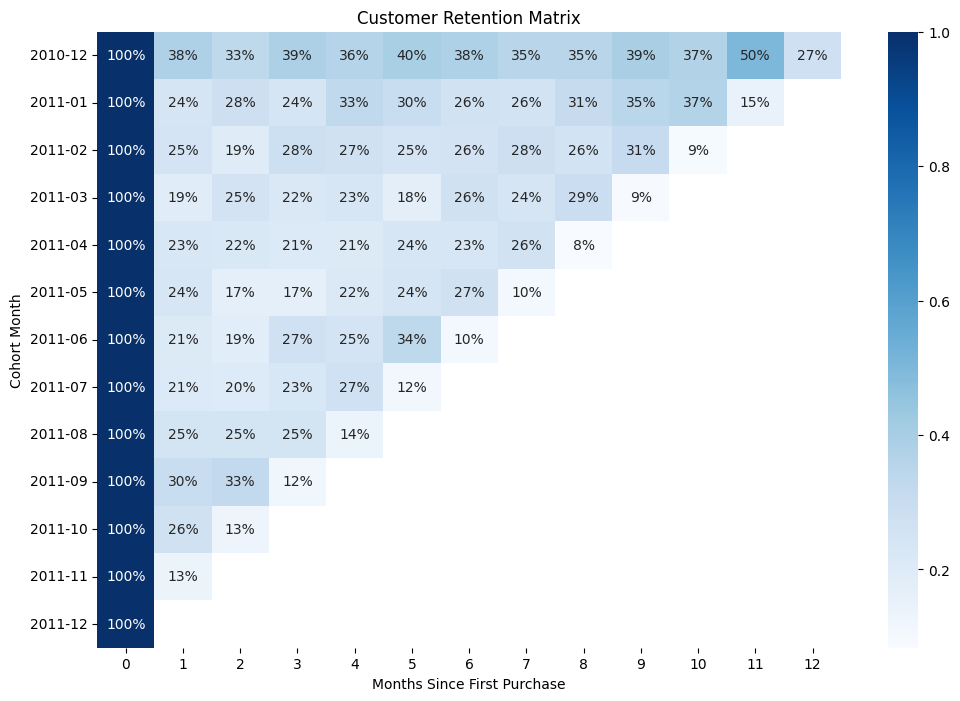

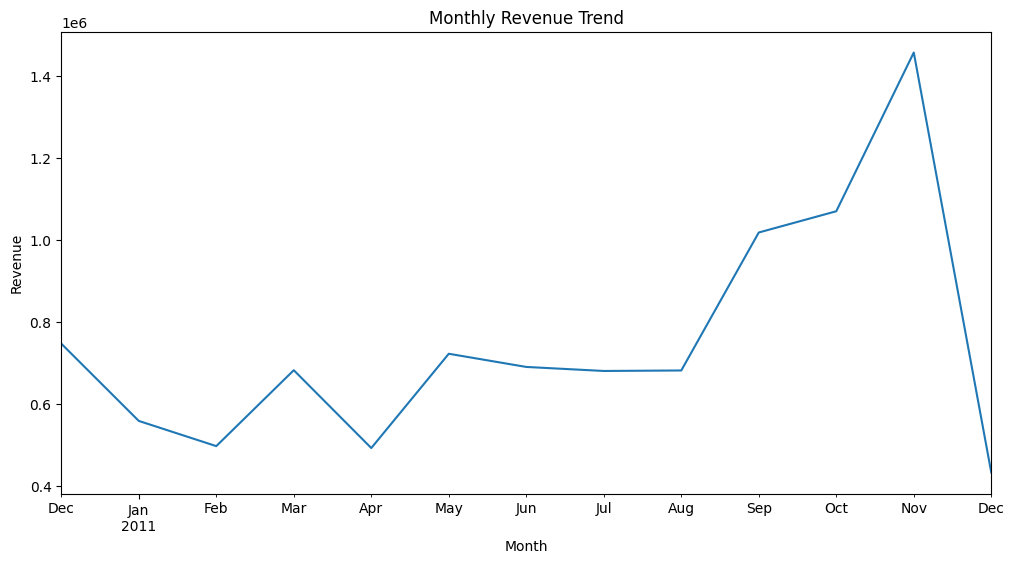

In [29]:
#Retention Heatmap-

plt.figure(figsize=(12,8))

sns.heatmap(
retention_matrix,
annot=True,
fmt='.0%',
cmap='Blues'
)

plt.title("Customer Retention Matrix")

plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.show()


#Revenue Trend-

monthly_revenue = df.groupby('InvoiceMonth')['Revenue'].sum()

plt.figure(figsize=(12,6))

monthly_revenue.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()
